#**Spam Classificaion Models: Navie Bayes,Decion Tree(CART&ID3),Random Forest,**

In [2]:
#import Libries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Load dataset

In [3]:
df=pd.read_csv("/content/drive/MyDrive/MSC/ML_ALL_PROGRAM_DS_SEM_2/18_Mar/spambase.csv")



In [4]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
df.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


#Split Features & target


In [8]:
X=df.drop('spam',axis=1)
y=df['spam']

# train Test Split


In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


#Features Scaling

In [10]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Creates Dictionary To Store all model Result

In [23]:
results = {}


#Navie Bayes

In [25]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)
results['Naive Bayes'] = accuracy_score(y_test, nb_pred)

print("\ Naive Bayes Accuracy:", results['Naive Bayes'])


1. Naive Bayes Accuracy: 0.8219326818675353


#Decision Tree (Cart)

In [26]:
cart_model = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_model.fit(X_train_scaled, y_train)
cart_pred = cart_model.predict(X_test_scaled)
results['DT (CART)'] = accuracy_score(y_test, cart_pred)

print("Decision Treeaccuracy:", results['DT (CART)'])

2. Decision Tree (CART) Accuracy: 0.9196525515743756


#Decision Tree ID3

In [27]:
id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_model.fit(X_train_scaled, y_train)
id3_pred = id3_model.predict(X_test_scaled)
results['DT (ID3)'] = accuracy_score(y_test, id3_pred)

print("DecisionTree ID3 Accuracy:", results['DT (ID3)'])


3. Decision Tree (ID3) Accuracy: 0.9315960912052117


#Random Forest

In [28]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
results['Random Forest'] = accuracy_score(y_test, rf_pred)

print(" Random Forestaccuracy:", results['Random Forest'])

4. Random Forest Accuracy: 0.9554831704668838


#

#Svm

In [30]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
results['SVM'] = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", results['SVM'])

5. SVM Accuracy: 0.9348534201954397


#Visualization

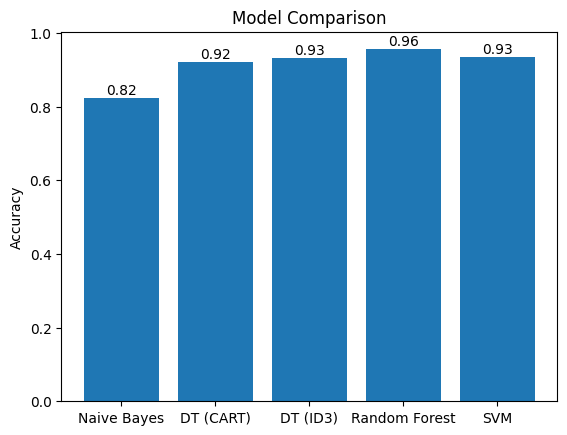

In [31]:

models = list(results.keys())
accuracies = list(results.values())

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [34]:

for model, acc in results.items():
    print(f"{model:15} : {acc:.4f}")

Naive Bayes     : 0.8219
DT (CART)       : 0.9197
DT (ID3)        : 0.9316
Random Forest   : 0.9555
SVM             : 0.9349
